# Evidence-Aware Multi-Agent RAG for Scientific Literature Review

**CSE427 Final Project — Group 10**

This faculty-ready notebook reproduces the project setup, validates the QASPER processing pipeline, runs a small real validation-only demonstration, and presents committed experimental results. Our contributions are paragraph-aware preprocessing, a unified paragraph/section/figure-table corpus, hybrid retrieval with evidence-aware reranking, and a traceable five-agent answer workflow.

## A. Project objective and contributions

The research objective is to test whether explicit evidence selection and bounded multi-agent critique improve the transparency and practical behavior of scientific question answering. Inference and gold evaluation are deliberately separate: the live demo reads question metadata only, while the result section loads previously committed aggregate validation results.

## B. System architecture and five agents

`Question → Query Agent → Retrieval Agent (BM25 + BGE dense + weighted RRF) → Evidence Agent (cross-encoder + fused scoring, E1–E5) → Answer Agent (Qwen) → Critic Agent → answer, citations, public trace`

The Query Agent normalizes the request; Retrieval combines paper-scoped lexical and dense candidates; Evidence reranks and labels five sources; Answer generates only from selected evidence; Critic performs deterministic citation/grounding checks plus one bounded review/revision.

## C. Environment and dependency setup

In [1]:
# Execution controls: defaults never rerun the fixed 100-question generation experiment.
QUICK_DEMO = True
RUN_FULL_GENERATION = False
REBUILD_INDEX_IF_MISSING = True
DEMO_QUESTION_COUNT = 3
SEED = 427

REPOSITORY_URL = "https://github.com/raiyanhossainaraf-dagger/CSE427Labproject_S3_G10.git"
REPOSITORY_DIR = "CSE427Labproject_S3_G10"
DENSE_MODEL = "BAAI/bge-small-en-v1.5"
RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L6-v2"
GENERATION_MODEL = "Qwen/Qwen3-4B-Instruct-2507"  # recommended final Colab model
BACKEND_COMPATIBILITY_DEFAULT = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_NEW_TOKENS = 256
GENERATION_BATCH_SIZE = 1

assert 3 <= DEMO_QUESTION_COUNT <= 5
if RUN_FULL_GENERATION:
    raise RuntimeError("The final notebook never reruns the 100-question experiment. Use CSE427_LLM_Ablation.ipynb for full reproduction.")


In [2]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    candidate = Path("/content") / REPOSITORY_DIR
    if not candidate.exists():
        subprocess.run(["git", "clone", REPOSITORY_URL, str(candidate)], check=True)
    PROJECT_ROOT = candidate
    os.chdir(PROJECT_ROOT)
else:
    current = Path.cwd().resolve()
    PROJECT_ROOT = next((p for p in (current, *current.parents) if (p / "src").is_dir() and (p / "requirements-colab.txt").is_file()), None)
    if PROJECT_ROOT is None:
        raise RuntimeError("Run locally from this repository, or open the notebook in Colab.")

subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements-colab.txt", "-r", "requirements-llm.txt", "transformers>=4.51.0"], check=True)
print({"in_colab": IN_COLAB, "project_root": str(PROJECT_ROOT)})


{'in_colab': True, 'project_root': '/content/CSE427Labproject_S3_G10'}


In [3]:
import gc, json, platform, random
import numpy as np
import pandas as pd
import torch
import transformers
from packaging.version import Version
from IPython.display import display, Markdown
from src.utils import set_seed

set_seed(SEED); random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
assert Version(transformers.__version__) >= Version("4.51.0"), "Qwen3 requires transformers>=4.51.0"
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for the final Qwen3 Colab demonstration; CPU and local 8 GB FP16 execution are not recommended.")
torch.cuda.manual_seed_all(SEED)
required = ["requirements-colab.txt", "requirements-llm.txt", "data/processed/questions.parquet",
            "outputs/tables/g5_answer_comparison.csv", "outputs/tables/g5_retrieval_comparison.csv",
            "outputs/tables/g7_llm_ablation.csv", "outputs/summaries/g7_llm_ablation_summary.json"]
missing = [p for p in required if not (PROJECT_ROOT / p).is_file()]
if missing: raise FileNotFoundError(f"Required repository files missing: {missing}")
env = {"python": platform.python_version(), "transformers": transformers.__version__,
       "cuda_available": True, "cuda_version": torch.version.cuda, "gpu": torch.cuda.get_device_name(0)}
display(env)


{'python': '3.13.15',
 'transformers': '5.15.1',
 'cuda_available': True,
 'cuda_version': '12.8',
 'gpu': 'Tesla T4'}

## D. QASPER dataset statistics and schema

QASPER contains questions grounded in NLP papers. The committed schema separates papers, sections, paragraphs, questions, answers, evidence, and figures/tables. The test data may exist as source data, but this notebook neither evaluates nor reports test-split performance.

In [4]:
dataset_summary = json.loads((PROJECT_ROOT / "outputs/summaries/dataset_summary.json").read_text())
schema_summary = json.loads((PROJECT_ROOT / "outputs/summaries/qasper_schema_summary.json").read_text())
display(dataset_summary, schema_summary)

{'dataset': 'QASPER',
 'splits': {'train': 888, 'test': 416, 'validation': 281},
 'total_papers': 1585,
 'total_questions': 5049,
 'total_evidence_items': 12761,
 'average_document_words': 3572.845425867508,
 'average_question_words': 8.13903743315508,
 'generated_chunks': 29360}

{'schema_version': '1.1.0',
 'table_counts': {'papers': 1585,
  'sections': 23494,
  'paragraphs': 83087,
  'questions': 5049,
  'answers': 7993,
  'evidence': 12761,
  'figures_tables': 11364},
 'split_counts': {'train': 888, 'test': 416, 'validation': 281},
 'answer_types': {'extractive': 4142,
  'abstractive': 1931,
  'unanswerable': 810,
  'yes': 611,
  'no': 499},
 'evidence_types': {'text': 11663, 'figure_table': 1098},
 'status': 'validated'}

## E. Evidence mapping and validation

In [5]:
mapping_summary = json.loads((PROJECT_ROOT / "outputs/summaries/evidence_mapping_summary.json").read_text())
assert mapping_summary["unmatched"] == 0 if "unmatched" in mapping_summary else mapping_summary["status_counts"]["unmatched"] == 0
display(mapping_summary)

{'total_evidence': 12761,
 'status_counts': {'matched': 12732, 'ambiguous': 29, 'unmatched': 0},
 'matched_coverage': 0.9977274508267377,
 'candidate_mapping_coverage': 1.0,
 'mapping_rows': 13023,
 'source_type_rows': {'paragraph': 11427, 'float': 1098, 'section': 498}}

## F. Paragraph-aware chunking

Chunks preserve paragraph identifiers and controlled overlap instead of treating papers as undifferentiated text. The committed summary below is descriptive; rebuilding the retrieval corpus uses the repository implementation in `src.retrieval_corpus`.

In [6]:
chunking_summary = json.loads((PROJECT_ROOT / "outputs/summaries/chunking_summary.json").read_text())
display(chunking_summary)

{'total_chunks': 39398,
 'chunks_per_split': {'train': 22906, 'test': 9789, 'validation': 6703},
 'token_stats': {'count': 39398.0,
  'mean': 219.07320168536475,
  'std': 95.9830038753211,
  'min': 1.0,
  '25%': 143.0,
  '50%': 229.0,
  '75%': 303.0,
  'max': 374.0},
 'is_partial_stats': {'false': 37485, 'true': 1913},
 'chunking_config': {'tokenizer_name': 'sentence-transformers/all-MiniLM-L6-v2',
  'max_tokens': 384,
  'overlap_tokens': 32}}

## G. Unified paragraph/section/figure-table retrieval corpus

In [7]:
from src.config import RETRIEVAL_ARTIFACT_VERSION
artifact_dir = PROJECT_ROOT / "data/processed" / RETRIEVAL_ARTIFACT_VERSION
corpus_path = artifact_dir / "corpus.parquet"
if not corpus_path.exists():
    subprocess.run([sys.executable, "scripts/build_retrieval_corpus.py"], cwd=PROJECT_ROOT, check=True)
corpus = pd.read_parquet(corpus_path)
display(corpus.groupby(["split", "source_type"]).size().rename("documents").to_frame())

documents
split      source_type           
test       chunk             9789
           float             2878
           section           6076
train      chunk            22906
           float             6557
           section          13322
validation chunk             6703
           float             1929
           section           4076

## H. Dense index construction when ignored artifacts are absent

In [8]:
dense_required = ["passage_embeddings.f32.npy", "index_flat_ip.faiss", "document_map.parquet", "dense_manifest.json"]
dense_missing = [name for name in dense_required if not (artifact_dir / name).exists()]
if dense_missing:
    if not REBUILD_INDEX_IF_MISSING:
        raise FileNotFoundError(f"Dense artifacts missing and rebuild disabled: {dense_missing}")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    subprocess.run([sys.executable, "scripts/build_dense_index.py", "--device", device], cwd=PROJECT_ROOT, check=True)
display(json.loads((artifact_dir / "dense_manifest.json").read_text()))

{'artifact_version': 'retrieval_v2',
 'model': 'BAAI/bge-small-en-v1.5',
 'dimension': 384,
 'row_count': 74236,
 'corpus_fingerprint': '8e7e45710cc8491e684fd1f9f7d7030749648291f8ae04f49fffca1c8fe9e154',
 'normalization': 'L2',
 'index_type': 'IndexFlatIP',
 'dtype': 'float32',
 'device': 'cuda:0',
 'batch_size': 32,
 'build_seconds': 565.3689239800001}

## I. BM25, dense, hybrid RRF and evidence-aware reranking

The repository implements BM25 and BGE dense retrieval over the unified corpus, combines rankings with weighted reciprocal-rank fusion, then applies `cross-encoder/ms-marco-MiniLM-L6-v2` and the frozen evidence fusion rule. Missing requested models raise errors; no model is silently substituted.

In [9]:
from src.bm25_retrieval import PaperScopedBM25Retriever
from src.embeddings import load_embedding_model
from src.hybrid_retrieval import HybridRetriever
from src.reranker import CrossEncoderReranker
print({"dense": DENSE_MODEL, "reranker": RERANKER_MODEL, "rrf": "src.hybrid_retrieval.weighted_rrf"})

{'dense': 'BAAI/bge-small-en-v1.5', 'reranker': 'cross-encoder/ms-marco-MiniLM-L6-v2', 'rrf': 'src.hybrid_retrieval.weighted_rrf'}


## J. Query, Retrieval, Evidence, Answer and Critic Agents

In [10]:
from src.query_agent import QueryAgent
from src.retrieval_agent import RetrievalAgent
from src.evidence_agent import EvidenceAgent
from src.answer_agent import AnswerAgent
from src.critic_agent import CriticAgent
from src.llm_backend import TransformersLLMBackend
from src.orchestrator import MultiAgentOrchestrator
print([QueryAgent.__name__, RetrievalAgent.__name__, EvidenceAgent.__name__, AnswerAgent.__name__, CriticAgent.__name__])

['QueryAgent', 'RetrievalAgent', 'EvidenceAgent', 'AnswerAgent', 'CriticAgent']


## K. Small real end-to-end validation demonstration

This gold-free inference cell explicitly uses `Qwen/Qwen3-4B-Instruct-2507` on 3–5 deterministically selected validation questions. CUDA and `transformers>=4.51.0` are required. Generation is CUDA FP16, greedy (`do_sample=False`), `max_new_tokens=256`, batch size 1. The saved ablation peaked at 9008.56–9023.42 MB (approximately 9 GB), reflecting Qwen3 FP16 model weights plus activations and CUDA allocator overhead; local 8 GB FP16 execution is not recommended.


In [11]:
# Gold-free live inference boundary.
questions = pd.read_parquet(PROJECT_ROOT / "data/processed/questions.parquet")
for forbidden in ("answer", "answers", "evidence", "gold_answer", "gold_evidence"):
    assert forbidden not in questions.columns
demo_questions = questions.loc[questions.split.eq("validation"), ["question_id", "paper_id", "split", "question"]].sort_values(
    ["paper_id", "question_id"], kind="stable").head(DEMO_QUESTION_COUNT)
display(demo_questions)

,question_id,paper_id,split,question
2596,02428a8fec9788f6dc3a86b5d5f3aa679935678d,1503.00841,validation,How do they define robustness of a model?
2593,50be4a737dc0951b35d139f51075011095d77f2a,1503.00841,validation,What background knowledge do they leverage?
2594,6becff2967fe7c5256fe0b00231765be5b9db9f1,1503.00841,validation,What are the three regularization terms?


In [12]:
from scripts.run_multi_agent_demo import build_flow
from src.llm_backend import DEFAULT_MODEL_NAME

assert DEFAULT_MODEL_NAME == BACKEND_COMPATIBILITY_DEFAULT  # preserve Qwen2.5 compatibility default
assert GENERATION_MODEL == "Qwen/Qwen3-4B-Instruct-2507"
demo_results = []
if QUICK_DEMO:
    backend = TransformersLLMBackend(model_name=GENERATION_MODEL, max_new_tokens=MAX_NEW_TOKENS, device="cuda")
    assert backend.generation_config == {"do_sample": False, "max_new_tokens": 256, "batch_size": 1}
    flow = build_flow(PROJECT_ROOT, backend, device="cuda", use_llm_critic=True)
    for row in demo_questions.itertuples(index=False):
        demo_results.append(flow.run(str(row.question_id), row.question, str(row.paper_id), "validation"))
    gc.collect(); torch.cuda.empty_cache()
else:
    print("QUICK_DEMO=False: live inference skipped.")


Loading embedding model: BAAI/bge-small-en-v1.5 on device: cuda...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

...

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

## L. Questions, E1–E5 evidence, answers, citations and public traces

In [13]:
for result in demo_results:
    display(Markdown(f"### {result.question}\n\n**Final answer:** {result.answer}\n\n**Citations:** " +
                     (", ".join(c["label"] for c in result.citations) or "None") +
                     f"\n\n**Public trace status:** `{result.final_status}`"))
    evidence_rows = [{"label": e["citation_label"], "source_type": e["source_type"],
                      "source_id": e["source_id"], "section": e["section_name"], "title": e["title"],
                      "evidence": e["evidence_text"]} for e in result.selected_evidence]
    display(pd.DataFrame(evidence_rows))
    display(pd.DataFrame(result.agent_traces)[["agent_name", "status", "output_count", "decisions"]])

### How do they define robustness of a model?

**Final answer:** Robustness of a model in this context is defined as the model's ability to perform well and maintain performance despite variations or uncertainties in the prior knowledge supplied, particularly in terms of sensitivity to the knowledge input. The paper introduces regularization terms—such as those for neutral features, maximum entropy of class distribution, and KL divergence—to formalize prior knowledge and improve robustness. Experimental results show that these methods are more robust than baselines, especially in handling unbalanced labeled features and varying class distributions. The robustness is demonstrated through improved performance and stability when the model is exposed to different types of prior knowledge, such as neutral features or class distribution assumptions.

**Citations:** E1, E3, E5

**Public trace status:** `accepted`

,label,source_type,source_id,section,title,evidence
0,E1,chunk,0d9d32a2d3d6cb184c8fbe30c204e29d70e947ea6a349a...,Abstract,Robustly Leveraging Prior Knowledge in Text Cl...,prior knowledge has been shown very useful to ...
1,E2,chunk,1d7ccf360c46cdd6e64ea8d6a5feb9cf7c604ef5d31436...,Related Work,Robustly Leveraging Prior Knowledge in Text Cl...,"mann and mccallum simple, generalized incorpor..."
2,E3,chunk,ea05a9ea25c9b8a965378b4d2b65b3074f9c281edbbecd...,Conclusion and Discussions,Robustly Leveraging Prior Knowledge in Text Cl...,this paper investigates into the problem of ho...
3,E4,chunk,ca621c8f1b1c7b43661aa81fa7883bb3e2e03d5b831e97...,Method,Robustly Leveraging Prior Knowledge in Text Cl...,we address the robustness problem on top of ge...
4,E5,chunk,f34d726fd600b797c2a6c85fcbe988112a92bbc6d4d521...,Introduction,Robustly Leveraging Prior Knowledge in Text Cl...,"in this paper, we investigate into the problem..."


,agent_name,status,output_count,decisions
0,query_agent,ok,1,"[style=free-form, rewritten=False]"
1,retrieval_agent,ok,38,"[scope=paper+split, canonical_deduplication=tr..."
2,evidence_agent,ok,5,"[configuration=70/25/5, max_sources=5, citatio..."
3,answer_agent,ok,1,"[llm_called=true, validated_citations=3]"
4,critic_agent,ok,1,"[verdict=accept, critic_mode=llm, fallback_use..."


### What background knowledge do they leverage?

**Final answer:** They leverage prior knowledge such as words indicating specific categories (e.g., 'nba', 'player', 'basketball' for sports) and sentiment polarity (e.g., 'terrible', 'boring' for negative, 'perfect', 'exciting' for positive), as well as labeled features like 'amazing', 'exciting' for positive sentiment classification. They also use class distribution and neutral features to guide the learning process, and incorporate knowledge through methods like generalized expectation criteria and posterior regularization.

**Citations:** E1, E3, E4, E5

**Public trace status:** `accepted`

,label,source_type,source_id,section,title,evidence
0,E1,chunk,63afe5c35f2a56d41d3d64c86e619b24aee8745487b6a2...,Introduction,Robustly Leveraging Prior Knowledge in Text Cl...,we posses a wealth of prior knowledge about ma...
1,E2,chunk,ea05a9ea25c9b8a965378b4d2b65b3074f9c281edbbecd...,Conclusion and Discussions,Robustly Leveraging Prior Knowledge in Text Cl...,this paper investigates into the problem of ho...
2,E3,chunk,ca621c8f1b1c7b43661aa81fa7883bb3e2e03d5b831e97...,Method,Robustly Leveraging Prior Knowledge in Text Cl...,we address the robustness problem on top of ge...
3,E4,chunk,d16456bbfad721bf0e4f24ba7ec4d0d6a9fed1edf291ba...,Related Work,Robustly Leveraging Prior Knowledge in Text Cl...,there have been much work that incorporate pri...
4,E5,chunk,1d7ccf360c46cdd6e64ea8d6a5feb9cf7c604ef5d31436...,Related Work,Robustly Leveraging Prior Knowledge in Text Cl...,"mann and mccallum simple, generalized incorpor..."


,agent_name,status,output_count,decisions
0,query_agent,ok,1,"[style=extractive, rewritten=False]"
1,retrieval_agent,ok,38,"[scope=paper+split, canonical_deduplication=tr..."
2,evidence_agent,ok,5,"[configuration=70/25/5, max_sources=5, citatio..."
3,answer_agent,ok,1,"[llm_called=true, validated_citations=4]"
4,critic_agent,ok,1,"[verdict=accept, critic_mode=llm, fallback_use..."


### What are the three regularization terms?

**Final answer:** the three regularization terms are: (1) a regularization term associated with neutral features, (2) the maximum entropy of class distribution regularization term, and (3) the kl divergence between reference and predicted class distribution

**Citations:** E1, E3

**Public trace status:** `accepted`

,label,source_type,source_id,section,title,evidence
0,E1,chunk,ea05a9ea25c9b8a965378b4d2b65b3074f9c281edbbecd...,Conclusion and Discussions,Robustly Leveraging Prior Knowledge in Text Cl...,this paper investigates into the problem of ho...
1,E2,chunk,0d9d32a2d3d6cb184c8fbe30c204e29d70e947ea6a349a...,Abstract,Robustly Leveraging Prior Knowledge in Text Cl...,prior knowledge has been shown very useful to ...
2,E3,chunk,f34d726fd600b797c2a6c85fcbe988112a92bbc6d4d521...,Introduction,Robustly Leveraging Prior Knowledge in Text Cl...,"in this paper, we investigate into the problem..."
3,E4,chunk,1f658d5c61608cbb8375aeb912b511e0575b3f5a2fdc49...,Regularization Terms,Robustly Leveraging Prior Knowledge in Text Cl...,ge - fl reduces the heavy load of instance ann...
4,E5,section,1503.00841::section::full_text::4,Regularization Terms,Robustly Leveraging Prior Knowledge in Text Cl...,Regularization Terms


,agent_name,status,output_count,decisions
0,query_agent,ok,1,"[style=extractive, rewritten=False]"
1,retrieval_agent,ok,38,"[scope=paper+split, canonical_deduplication=tr..."
2,evidence_agent,ok,5,"[configuration=70/25/5, max_sources=5, citatio..."
3,answer_agent,ok,1,"[llm_called=true, validated_citations=2]"
4,critic_agent,ok,1,"[verdict=accept, critic_mode=llm, fallback_use..."


## M. Saved G5 baseline and G7 Qwen3 results (no 100-question rerun)

The fixed sample contains exactly 100 validation questions. This section preserves and displays the original Qwen2.5 G5 baseline alongside the saved Qwen3 G7 ablation; it invokes neither generation nor gold evaluation. For full reproduction, use `CSE427_LLM_Ablation.ipynb`, not this final presentation notebook.


In [14]:
qwen2_results = pd.read_csv(PROJECT_ROOT / "outputs/tables/g5_answer_comparison.csv")
qwen3_results = pd.read_csv(PROJECT_ROOT / "outputs/tables/g7_llm_ablation.csv")
g7_summary = json.loads((PROJECT_ROOT / "outputs/summaries/g7_llm_ablation_summary.json").read_text())
retrieval_results = pd.read_csv(PROJECT_ROOT / "outputs/tables/g5_retrieval_comparison.csv")
sample = pd.read_csv(PROJECT_ROOT / "outputs/tables/g5_validation_sample.csv")
assert len(sample) == 100 and sample.question_id.nunique() == 100 and sample.split.eq("validation").all()
assert g7_summary["question_count"] == 100 and g7_summary["test_split_accessed"] is False
display(qwen2_results, qwen3_results, retrieval_results.query("k == 5"))

if RUN_FULL_GENERATION:
    raise RuntimeError("Use CSE427_LLM_Ablation.ipynb for explicit full reproduction; this notebook does not rerun 100-question inference.")


,configuration,question_count,official_answer_f1,citation_valid_record_count,citation_valid_record_rate,accepted_first_attempt,accepted_after_revision,rejected,insufficient_evidence_count,average_evidence_count,average_runtime_seconds,total_runtime_seconds,peak_gpu_memory_mb
0,dense_single_agent,100,0.295425,100,1.0,95,0,0,5,5.0,1.838351,183.875149,3771.95
1,evidence_aware_no_critic,100,0.269494,100,1.0,96,0,0,4,5.0,1.900071,190.030627,3771.95
2,full_multi_agent,100,0.270744,100,1.0,96,2,1,1,5.0,3.248512,324.873856,3771.95


,configuration,model,question_count,official_answer_f1,citation_label_valid_count,citation_label_valid_rate,accepted_first_attempt,accepted_after_revision,rejected,insufficient,runtime_per_question_seconds,total_runtime_seconds,peak_gpu_memory_mb
0,qwen3_dense_single_agent,Qwen/Qwen3-4B-Instruct-2507,100,0.319855,100,1.0,100,0,0,0,5.831563,585.210400,9023.42
1,qwen3_full_multi_agent,Qwen/Qwen3-4B-Instruct-2507,100,0.408218,100,1.0,89,4,7,0,9.840211,986.446258,9008.56
2,qwen2_dense_single_agent,Qwen/Qwen2.5-1.5B-Instruct,100,0.295425,100,1.0,95,0,0,5,1.838351,183.875149,3771.95
3,qwen2_full_multi_agent,Qwen/Qwen2.5-1.5B-Instruct,100,0.270744,100,1.0,96,2,1,1,3.248512,324.873856,3771.95


,scope,stage,method,k,hit_rate,precision,recall,evidence_f1,mrr,map,ndcg,evaluated_questions,excluded_questions
2,full_validation,retrieval,bm25,5,0.621359,0.140237,0.509437,0.207749,0.338242,0.278428,0.353003,927,78
7,full_validation,retrieval,dense,5,0.689320,0.164833,0.575395,0.241307,0.429414,0.355999,0.431164,927,78
12,full_validation,retrieval,hybrid,5,0.717368,0.169148,0.596533,0.248631,0.453398,0.375303,0.452173,927,78
17,full_validation,reranking,cross_encoder,5,0.756203,0.182309,0.638244,0.266192,0.482488,0.405857,0.485941,927,78
22,full_validation,reranking,evidence_fused,5,0.774542,0.187487,0.658020,0.274422,0.495289,0.419519,0.501048,927,78
27,full_validation,reranking,hybrid,5,0.717368,0.169148,0.596533,0.248631,0.453398,0.375303,0.452173,927,78


## N. Retrieval, reranking and Answer F1 comparison charts

Retrieval metrics cover **927 evidence-eligible validation questions**. Generation metrics cover a separate fixed deterministic **100-question validation sample**.

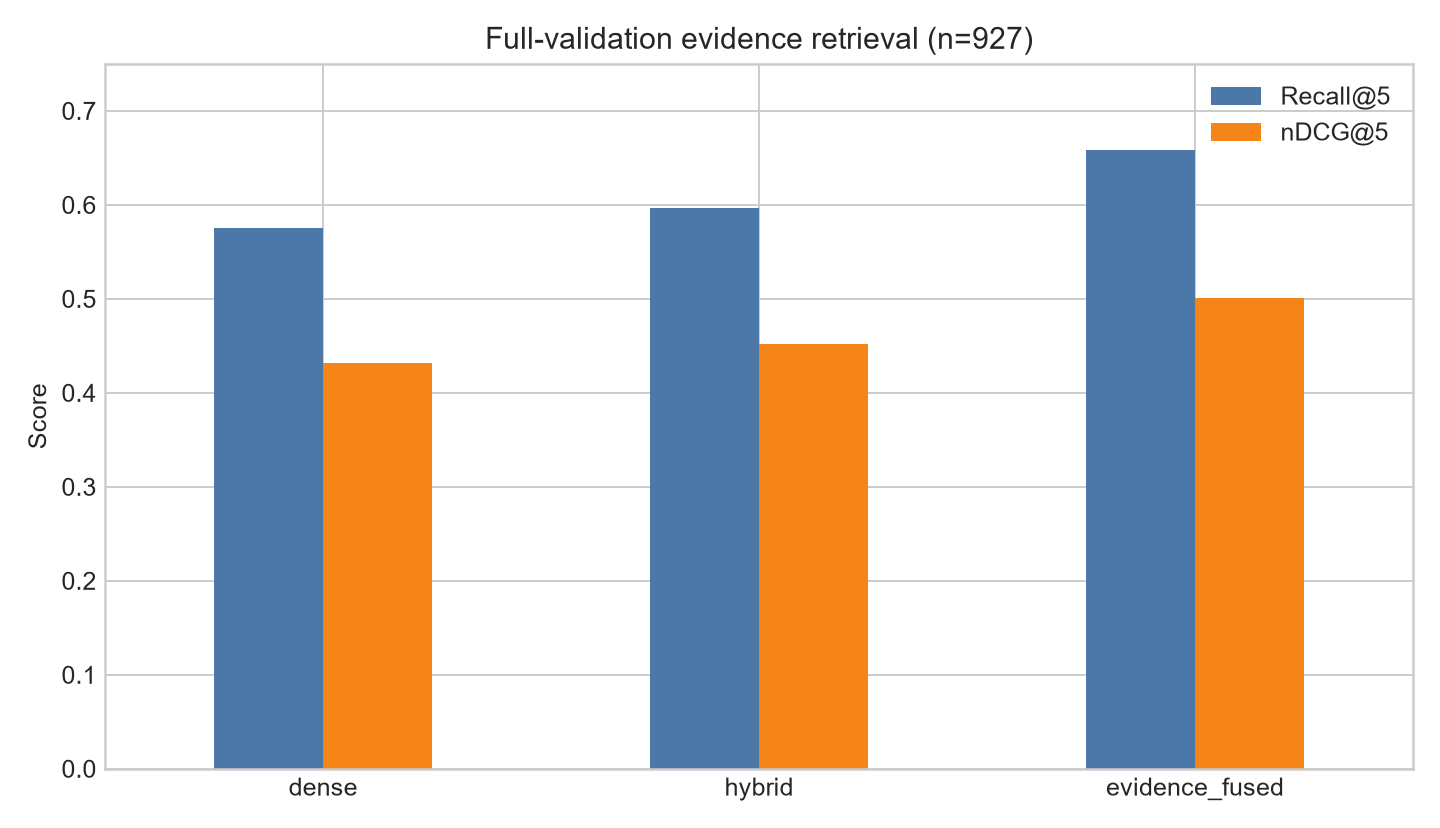

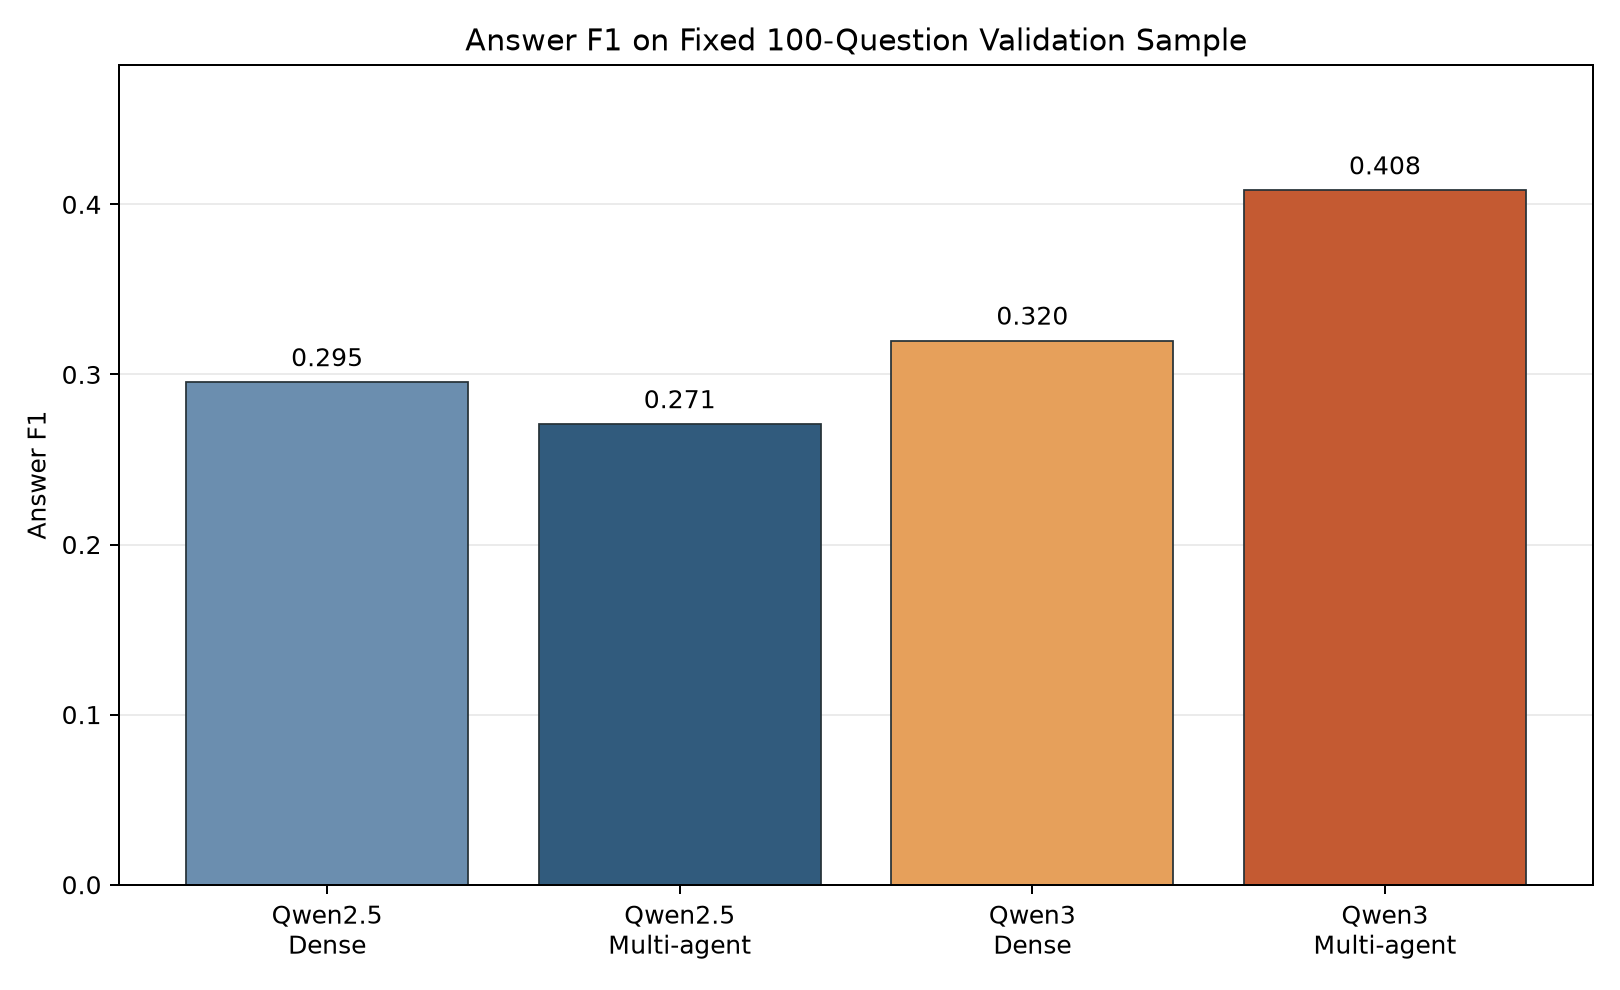

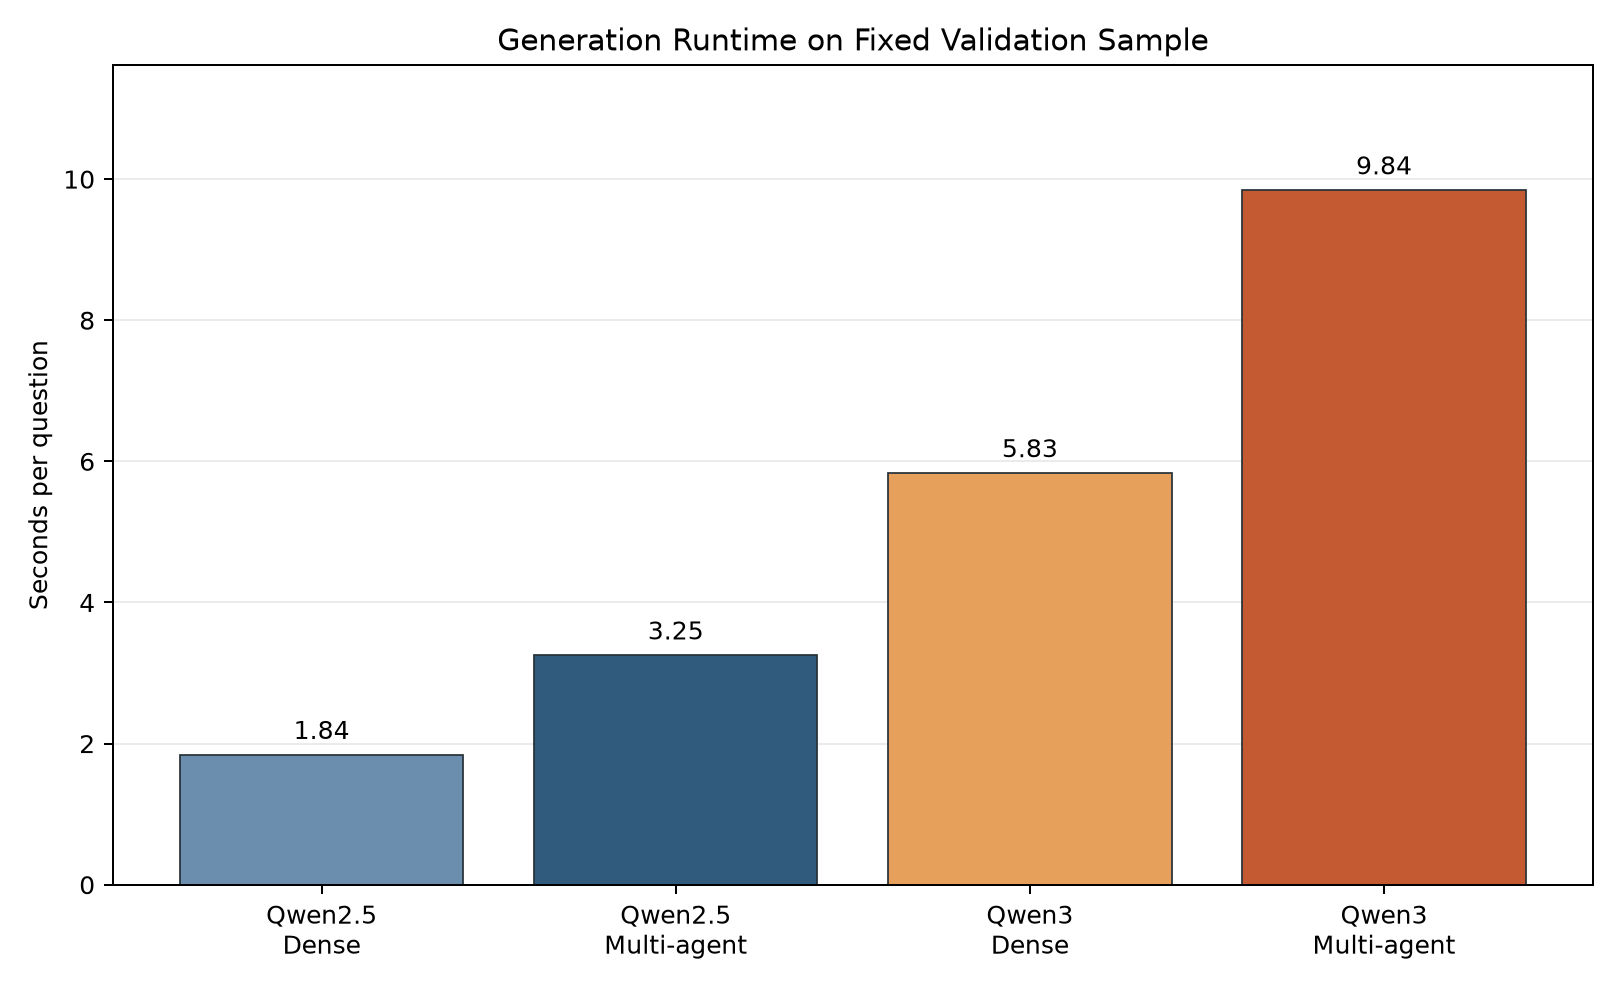

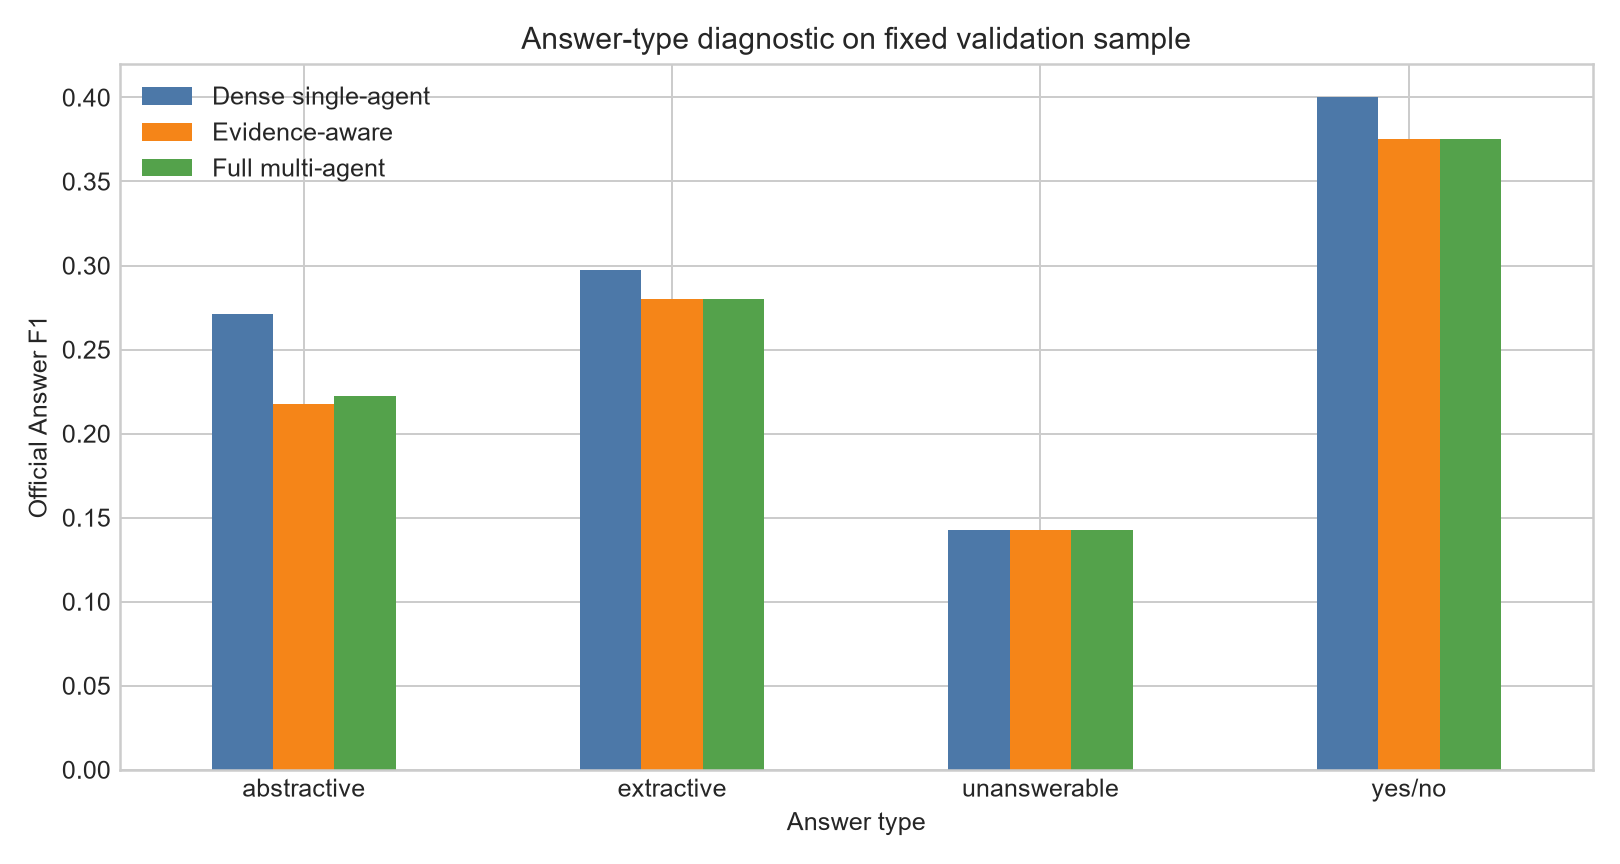

In [15]:
from IPython.display import Image
for filename in ["retrieval_comparison.png", "answer_f1_comparison.png", "runtime_comparison.png", "answer_type_diagnostic.png"]:
    display(Image(filename=str(PROJECT_ROOT / "figures" / filename)))

## O. Paired statistical diagnostic and interpretation

On the fixed 100-question validation sample, the Qwen3 full multi-agent system achieved 40.82% Answer F1 compared with 31.99% for the Qwen3 dense single-agent baseline. The paired difference was +8.84 percentage points, with a 95% bootstrap confidence interval of +3.29 to +14.95 points and p=0.0019. Wins/ties/losses were **40/36/24**.

Qwen3 full minus Qwen2.5 full was +13.75 points (95% CI +4.96 to +22.48, p=0.0020). Qwen3 dense minus Qwen2.5 dense was +2.44 points, but its interval includes zero (p=0.5098). This does not establish that every multi-agent/model combination improves F1: Qwen2.5 full remains below Qwen2.5 dense. The stronger Qwen3 generator was better able to use the evidence-aware pipeline on this exploratory sample.

Citation-label validity is structural: it only verifies references to selected E1–E5 records, not semantic correctness.


## P. Limitations, reproducibility and conclusion

- This is an exploratory validation ablation, not test-set confirmation, and contains only 100 validation questions; the test split remains untouched.
- Citation validity is structural rather than semantic, and Answer F1 is incomplete.
- Seven Qwen3 full-system records were rejected.
- Qwen3 full takes 9.8402 seconds/question and Qwen3 peaks at approximately 9 GB GPU memory; local 8 GB FP16 execution is not recommended.
- Full-validation retrieval and 100-question generation are distinct scopes; QASPER is domain-specific.

The Qwen2.5 results remain the original baseline and backend compatibility default. Qwen3 is the explicitly recommended final Colab model. The notebook runs only a small CUDA live demonstration by default and loads committed G7 results; use `CSE427_LLM_Ablation.ipynb` for full reproduction.
